In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa praat-parselmouth soundfile scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.9 MB/s eta 0:00:00


Found 360 .wav files | Segmentation: 2s-Windows-Non-Overlapping
  Processing file 1/360...
  Processing file 21/360...
  Processing file 41/360...
  Processing file 61/360...
  Processing file 81/360...
  Processing file 101/360...
  Processing file 121/360...
  Processing file 141/360...
  Processing file 161/360...
  Processing file 181/360...
  Processing file 201/360...
  Processing file 221/360...
  Processing file 241/360...
  Processing file 261/360...
  Processing file 281/360...
  Processing file 301/360...
  Processing file 321/360...
  Processing file 341/360...
Loaded: 426 samples | Skipped: 0 invalid clips

Feature matrix shape : (426, 41)
NaN: 0 | Inf: 0
Feature matrix is clean.

Running LOOCV (6 folds) | Random Forest | 2s-Windows-Non-Overlapping

  Actor 01 | Train:  353 | Test:  73 | Acc: 0.411 | Macro-F1: 0.351
  Actor 03 | Train:  351 | Test:  75 | Acc: 0.373 | Macro-F1: 0.290
  Actor 05 | Train:  347 | Test:  79 | Acc: 0.544 | Macro-F1: 0.442
  Actor 07 | Train:  35

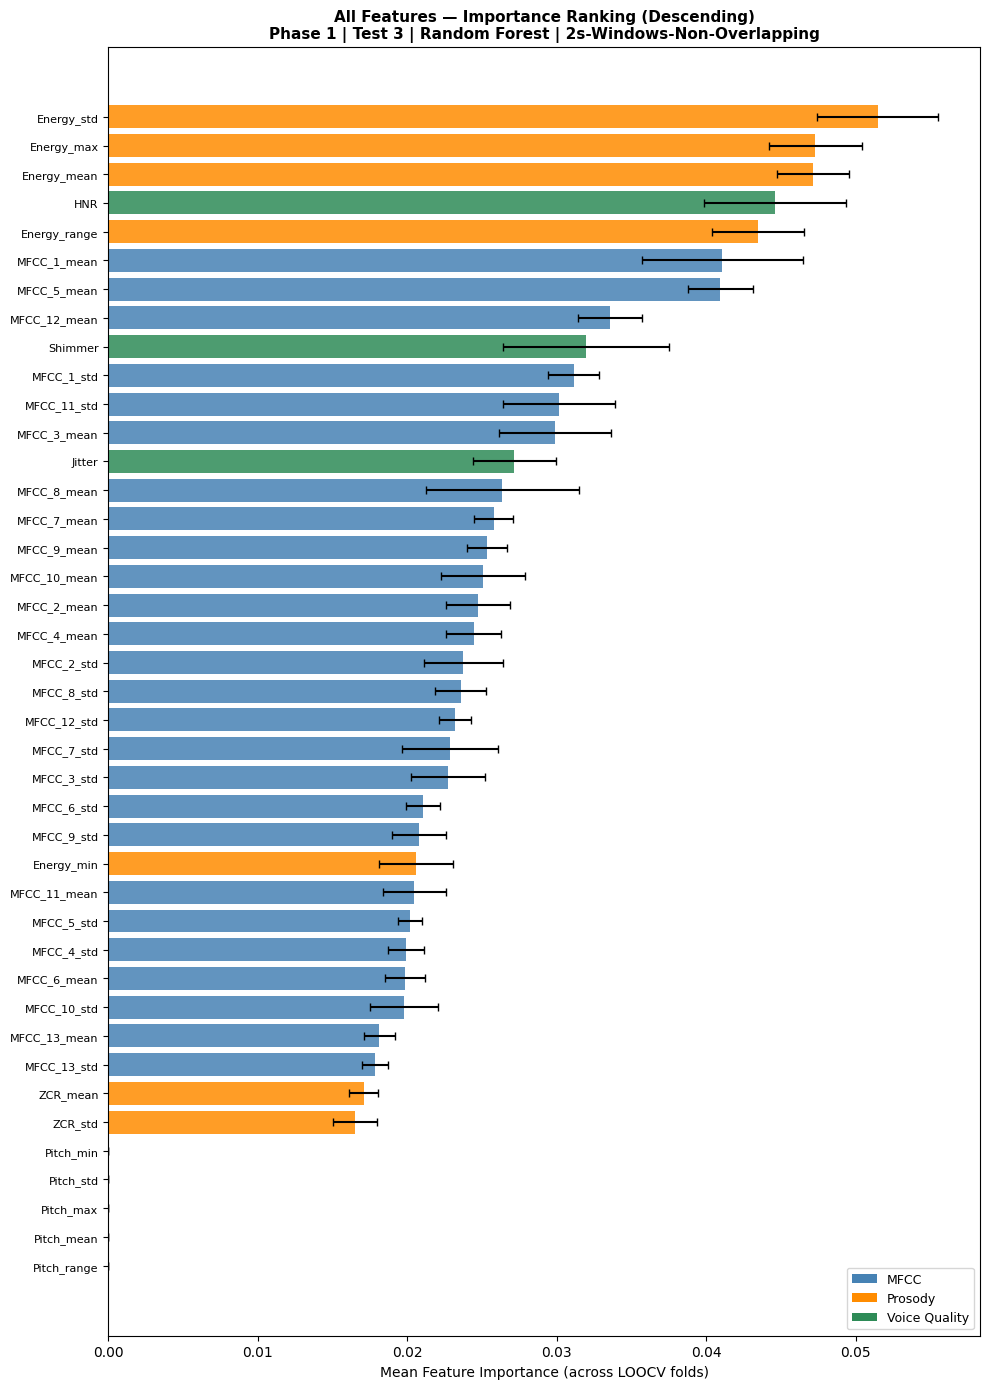

Saved: P1_T3_feature_importance_full.png


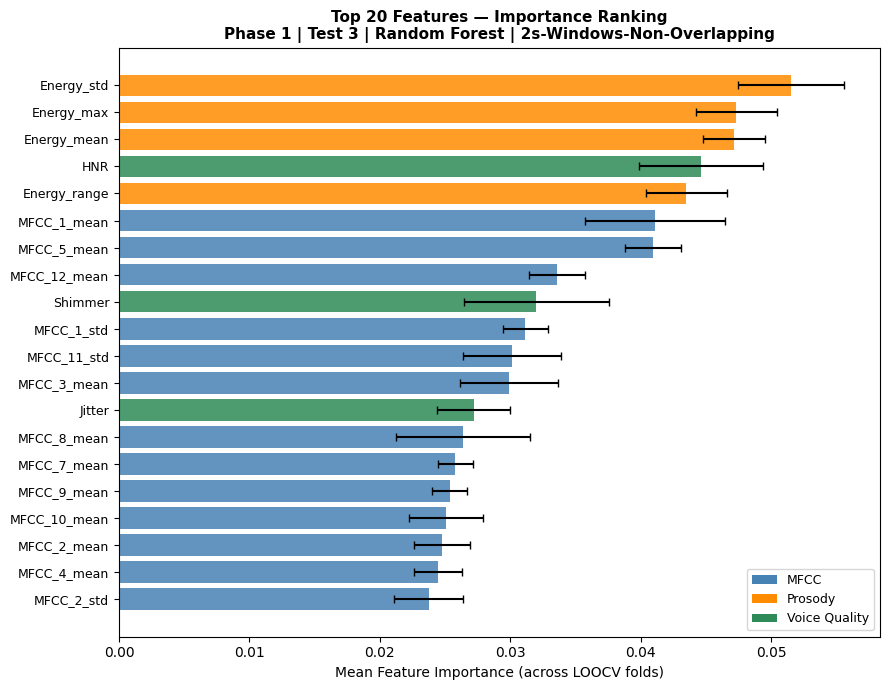

Saved: P1_T3_feature_importance_top20.png


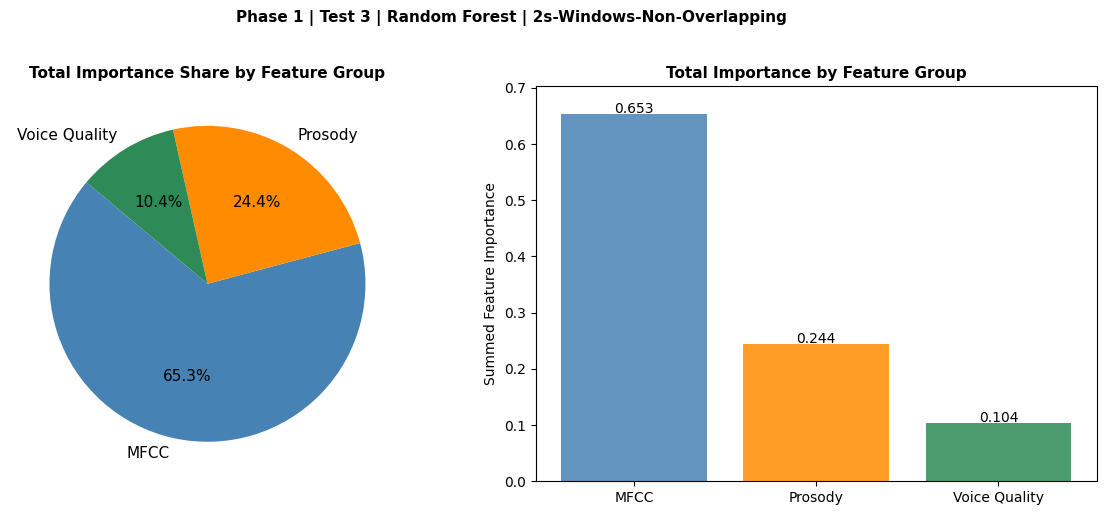

Saved: P1_T3_group_importance.png


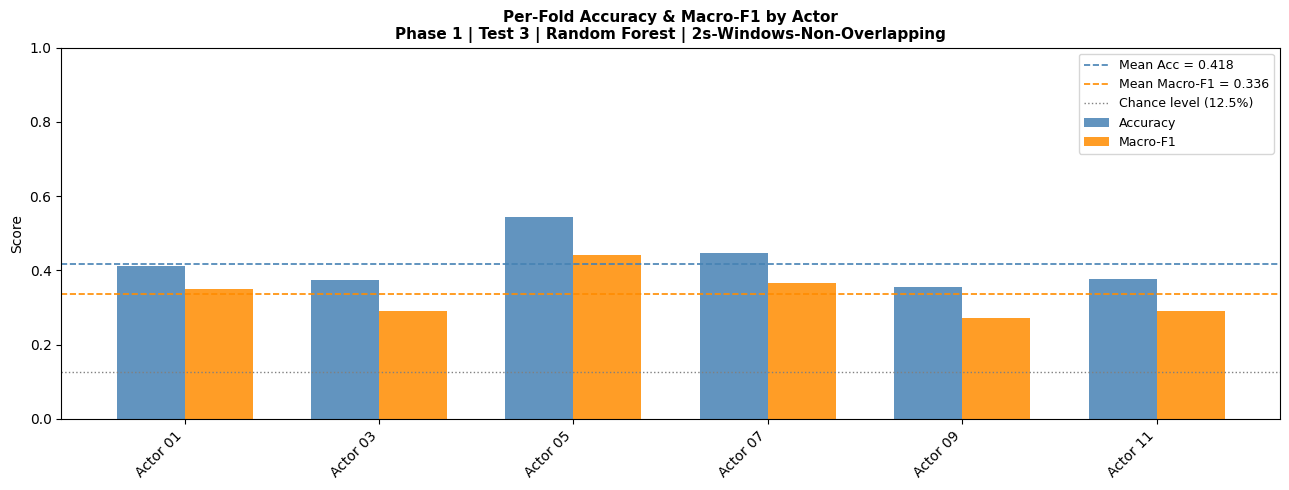

Saved: P1_T3_per_fold_performance.png

Saved: P1_T3_feature_importance.csv

Done. Phase 1 complete.


In [ ]:
# =============================================================================
# DAVIS - Phase 1, Test 3: Feature Importance via Random Forest
# Goal: Identify which individual acoustic features most strongly drive
#       emotion classification, to support discussion and interpretation
# Segmentation: 2s non-overlapping windows (best from Test 1)
# Model: Random Forest with LOOCV — feature importances averaged across folds
# =============================================================================

# Required installs (run once in Colab if not already installed):
# !pip install librosa parselmouth soundfile scikit-learn pandas matplotlib seaborn

import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import soundfile as sf
from parselmouth.praat import call
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)

# =============================================================================
# CONFIGURATION
# Segmentation locked to 2s non-overlapping (best from Phase 1 Test 1)
# =============================================================================

DATASET_PATH        = "/content/drive/My Drive/Neuroscience/Research/ravdess_male"
SAMPLE_RATE         = 16000
WINDOW_DURATION_SEC = 2
CONDITION_LABEL     = "2s-Windows-Non-Overlapping"

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised",
}
EMOTION_LABELS = list(emotion_map.values())

# Full feature names in extraction order — must match hstack in extract_features
FEATURE_NAMES = (
    [f"MFCC_{i+1}_mean" for i in range(13)] +
    [f"MFCC_{i+1}_std"  for i in range(13)] +
    ["Pitch_mean", "Pitch_std", "Pitch_min", "Pitch_max", "Pitch_range"] +
    ["Energy_mean", "Energy_std", "Energy_min", "Energy_max", "Energy_range"] +
    ["ZCR_mean", "ZCR_std"] +
    ["Jitter", "Shimmer", "HNR"]
)
assert len(FEATURE_NAMES) == 41, "Feature name list must have exactly 41 entries"

# Group label for each feature (used for colour-coding in plots)
FEATURE_GROUPS = (
    ["MFCC"] * 26 +
    ["Prosody"] * 12 +
    ["Voice Quality"] * 3
)
GROUP_PALETTE = {
    "MFCC":          "steelblue",
    "Prosody":       "darkorange",
    "Voice Quality": "seagreen",
}

# =============================================================================
# FEATURE EXTRACTION  (identical to Tests 1 & 2)
# =============================================================================

def extract_parselmouth_features(y, sr):
    temp_filename = "temp_praat.wav"
    try:
        sf.write(temp_filename, y, sr)
        snd           = parselmouth.Sound(temp_filename)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter        = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer       = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harmonicity   = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr           = call(harmonicity, "Get mean", 0, 0)
        jitter  = 0.0 if (jitter  is None or not np.isfinite(jitter))  else float(jitter)
        shimmer = 0.0 if (shimmer is None or not np.isfinite(shimmer)) else float(shimmer)
        hnr     = 0.0 if (hnr     is None or not np.isfinite(hnr))     else float(hnr)
    except Exception:
        jitter, shimmer, hnr = 0.0, 0.0, 0.0
    finally:
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    return [jitter, shimmer, hnr]


def extract_features(y_clip, sr):
    MIN_SAMPLES = int(0.1 * sr)
    if len(y_clip) < MIN_SAMPLES or np.max(np.abs(y_clip)) < 1e-6:
        return None

    mfccs      = librosa.feature.mfcc(y=y_clip, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std  = np.std(mfccs, axis=1)

    pitches, magnitudes = librosa.piptrack(y=y_clip, sr=sr)
    med = np.median(magnitudes)
    valid_pitches = pitches[magnitudes > med] if med > 0 else np.array([])
    valid_pitches = valid_pitches[valid_pitches > 0]
    pitch_mean  = float(np.mean(valid_pitches))  if len(valid_pitches) > 0 else 0.0
    pitch_std   = float(np.std(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_min   = float(np.min(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_max   = float(np.max(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_range = pitch_max - pitch_min

    energy       = librosa.feature.rms(y=y_clip)[0]
    energy_mean  = np.mean(energy)
    energy_std   = np.std(energy)
    energy_min   = np.min(energy)
    energy_max   = np.max(energy)
    energy_range = energy_max - energy_min

    zcr      = librosa.feature.zero_crossing_rate(y_clip)[0]
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    jitter, shimmer, hnr = extract_parselmouth_features(y_clip, sr)

    features = np.hstack([
        mfccs_mean, mfccs_std,
        [pitch_mean, pitch_std, pitch_min, pitch_max, pitch_range],
        [energy_mean, energy_std, energy_min, energy_max, energy_range],
        [zcr_mean, zcr_std],
        [jitter, shimmer, hnr]
    ])
    return np.where(np.isfinite(features), features, 0.0)

# =============================================================================
# DATA LOADING
# =============================================================================

def load_dataset(dataset_path, sr):
    X, y, actors  = [], [], []
    skipped_clips = 0

    files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".wav")])
    print(f"Found {len(files)} .wav files | Segmentation: {CONDITION_LABEL}")

    for i, file in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing file {i+1}/{len(files)}...")

        parts      = file.split('-')
        emotion_id = parts[2]
        actor_id   = parts[-1].split('.')[0]
        emotion    = emotion_map.get(emotion_id, "Unknown")
        if emotion == "Unknown":
            continue

        y_full, _ = librosa.load(os.path.join(dataset_path, file), sr=sr)
        samples_per_window = int(WINDOW_DURATION_SEC * sr)
        num_windows        = len(y_full) // samples_per_window

        for w in range(num_windows):
            start    = w * samples_per_window
            clip     = y_full[start:start + samples_per_window]
            features = extract_features(clip, sr)
            if features is None:
                skipped_clips += 1
                continue
            X.append(features)
            y.append(emotion)
            actors.append(actor_id)

    print(f"Loaded: {len(X)} samples | Skipped: {skipped_clips} invalid clips\n")
    return np.array(X), np.array(y), np.array(actors)

# =============================================================================
# LOOCV WITH RANDOM FOREST — COLLECT IMPORTANCE PER FOLD
# =============================================================================

def run_loocv_rf(X, y, actors):
    """
    LOOCV with Random Forest.
    Collects feature importances from every fold, then averages them.
    Also records per-fold accuracy and macro-F1 to confirm model is performing
    reasonably (importances are only meaningful if the model learns something).
    """
    unique_actors      = np.unique(actors)
    fold_importances   = []
    fold_metrics       = []
    all_y_true         = []
    all_y_pred         = []

    print(f"Running LOOCV ({len(unique_actors)} folds) | Random Forest | {CONDITION_LABEL}\n")

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Note: Random Forest does not require feature scaling,
        # but we scale anyway for consistency with other tests
        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train_sc, y_train)
        y_pred = rf.predict(X_test_sc)

        fold_importances.append(rf.feature_importances_)

        fold_acc = accuracy_score(y_test, y_pred)
        fold_f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
        fold_metrics.append({'actor': test_actor, 'accuracy': fold_acc, 'macro_f1': fold_f1})
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Actor {test_actor} | "
              f"Train: {len(y_train):4d} | Test: {len(y_test):3d} | "
              f"Acc: {fold_acc:.3f} | Macro-F1: {fold_f1:.3f}")

    # Average importances across all folds
    mean_importances = np.mean(fold_importances, axis=0)
    std_importances  = np.std(fold_importances,  axis=0)

    return mean_importances, std_importances, fold_metrics, np.array(all_y_true), np.array(all_y_pred)

# =============================================================================
# PLOTTING
# =============================================================================

def plot_feature_importance_full(mean_imp, std_imp, sorted_idx):
    """
    Horizontal bar chart — all 41 features sorted descending by importance.
    Bars are colour-coded by feature group.
    """
    names_sorted  = [FEATURE_NAMES[i]  for i in sorted_idx]
    groups_sorted = [FEATURE_GROUPS[i] for i in sorted_idx]
    imp_sorted    = mean_imp[sorted_idx]
    std_sorted    = std_imp[sorted_idx]
    colors        = [GROUP_PALETTE[g] for g in groups_sorted]

    fig, ax = plt.subplots(figsize=(10, 14))
    bars = ax.barh(
        range(len(sorted_idx)), imp_sorted,
        xerr=std_sorted, capsize=3,
        color=colors, alpha=0.85, align='center'
    )
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels(names_sorted, fontsize=8)
    ax.invert_yaxis()   # most important at top
    ax.set_xlabel("Mean Feature Importance (across LOOCV folds)", fontsize=10)
    ax.set_title(
        "All Features — Importance Ranking (Descending)\n"
        f"Phase 1 | Test 3 | Random Forest | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )

    # Legend for group colours
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=g)
                       for g, c in GROUP_PALETTE.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig("P1_T3_feature_importance_full.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: P1_T3_feature_importance_full.png")


def plot_feature_importance_top20(mean_imp, std_imp, sorted_idx):
    """
    Cleaner chart showing only the top 20 features — easier to read in a paper.
    """
    top_idx       = sorted_idx[:20]
    names_sorted  = [FEATURE_NAMES[i]  for i in top_idx]
    groups_sorted = [FEATURE_GROUPS[i] for i in top_idx]
    imp_sorted    = mean_imp[top_idx]
    std_sorted    = std_imp[top_idx]
    colors        = [GROUP_PALETTE[g] for g in groups_sorted]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(
        range(len(top_idx)), imp_sorted,
        xerr=std_sorted, capsize=3,
        color=colors, alpha=0.85, align='center'
    )
    ax.set_yticks(range(len(top_idx)))
    ax.set_yticklabels(names_sorted, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Mean Feature Importance (across LOOCV folds)", fontsize=10)
    ax.set_title(
        "Top 20 Features — Importance Ranking\n"
        f"Phase 1 | Test 3 | Random Forest | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=g)
                       for g, c in GROUP_PALETTE.items()]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig("P1_T3_feature_importance_top20.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: P1_T3_feature_importance_top20.png")


def plot_group_importance(mean_imp):
    """
    Pie + bar showing how much total importance each feature group holds.
    Useful for the discussion section.
    """
    group_totals = {}
    for name, group in zip(FEATURE_NAMES, FEATURE_GROUPS):
        idx = FEATURE_NAMES.index(name)
        group_totals[group] = group_totals.get(group, 0) + mean_imp[idx]

    groups = list(group_totals.keys())
    totals = [group_totals[g] for g in groups]
    colors = [GROUP_PALETTE[g] for g in groups]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pie
    axes[0].pie(totals, labels=groups, colors=colors, autopct='%1.1f%%',
                startangle=140, textprops={'fontsize': 11})
    axes[0].set_title("Total Importance Share by Feature Group",
                      fontsize=11, fontweight='bold')

    # Bar
    axes[1].bar(groups, totals, color=colors, alpha=0.85)
    for i, (g, t) in enumerate(zip(groups, totals)):
        axes[1].text(i, t + 0.002, f'{t:.3f}', ha='center', fontsize=10)
    axes[1].set_ylabel("Summed Feature Importance")
    axes[1].set_title("Total Importance by Feature Group",
                      fontsize=11, fontweight='bold')
    axes[1].set_ylim(0, max(totals) + 0.05)

    fig.suptitle(
        f"Phase 1 | Test 3 | Random Forest | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig("P1_T3_group_importance.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: P1_T3_group_importance.png")


def plot_per_fold_performance(fold_metrics):
    actor_labels = [f"Actor {m['actor']}" for m in fold_metrics]
    accs = [m['accuracy'] for m in fold_metrics]
    f1s  = [m['macro_f1'] for m in fold_metrics]

    x     = np.arange(len(actor_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue',  alpha=0.85)
    ax.bar(x + width/2, f1s,  width, label='Macro-F1', color='darkorange', alpha=0.85)
    ax.axhline(np.mean(accs), color='steelblue',  linestyle='--', linewidth=1.2,
               label=f'Mean Acc = {np.mean(accs):.3f}')
    ax.axhline(np.mean(f1s),  color='darkorange', linestyle='--', linewidth=1.2,
               label=f'Mean Macro-F1 = {np.mean(f1s):.3f}')
    ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
               label='Chance level (12.5%)')
    ax.set_xticks(x)
    ax.set_xticklabels(actor_labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    ax.set_title(
        "Per-Fold Accuracy & Macro-F1 by Actor\n"
        f"Phase 1 | Test 3 | Random Forest | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig("P1_T3_per_fold_performance.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: P1_T3_per_fold_performance.png")

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # 1. Load data
    X, y, actors = load_dataset(DATASET_PATH, SAMPLE_RATE)

    nan_count = int(np.isnan(X).sum())
    inf_count = int(np.isinf(X).sum())
    print(f"Feature matrix shape : {X.shape}")
    print(f"NaN: {nan_count} | Inf: {inf_count}")
    if nan_count > 0 or inf_count > 0:
        print("WARNING: NaN/Inf present — check feature extraction.")
    else:
        print("Feature matrix is clean.\n")

    # 2. Run LOOCV with Random Forest
    mean_imp, std_imp, fold_metrics, all_y_true, all_y_pred = run_loocv_rf(
        X, y, actors
    )

    # 3. Sort features by importance descending
    sorted_idx = np.argsort(mean_imp)[::-1]

    # 4. Print summary metrics
    accs = [m['accuracy'] for m in fold_metrics]
    f1s  = [m['macro_f1'] for m in fold_metrics]
    print("\n" + "="*65)
    print(f"LOOCV PERFORMANCE — Random Forest | {CONDITION_LABEL}")
    print("="*65)
    print(f"  Mean Accuracy : {np.mean(accs):.4f}  ±  {np.std(accs):.4f}")
    print(f"  Mean Macro-F1 : {np.mean(f1s):.4f}  ±  {np.std(f1s):.4f}")
    print()
    print("Overall classification report (aggregated across folds):")
    print(classification_report(
        all_y_true, all_y_pred,
        labels=EMOTION_LABELS,
        target_names=EMOTION_LABELS,
        zero_division=0
    ))

    # 5. Print ranked feature importances
    print("="*65)
    print("FEATURE IMPORTANCE RANKING (descending)")
    print("="*65)
    print(f"{'Rank':<5} {'Feature':<22} {'Group':<15} {'Mean Imp':>10} {'Std Imp':>10}")
    print("-"*65)
    for rank, idx in enumerate(sorted_idx, start=1):
        print(f"{rank:<5} {FEATURE_NAMES[idx]:<22} {FEATURE_GROUPS[idx]:<15} "
              f"{mean_imp[idx]:>10.5f} {std_imp[idx]:>10.5f}")

    # 6. Plots
    plot_feature_importance_full(mean_imp, std_imp, sorted_idx)
    plot_feature_importance_top20(mean_imp, std_imp, sorted_idx)
    plot_group_importance(mean_imp)
    plot_per_fold_performance(fold_metrics)

    # 7. Save CSV
    df_importance = pd.DataFrame({
        'rank':             range(1, 42),
        'feature':          [FEATURE_NAMES[i]  for i in sorted_idx],
        'group':            [FEATURE_GROUPS[i] for i in sorted_idx],
        'mean_importance':  mean_imp[sorted_idx],
        'std_importance':   std_imp[sorted_idx],
    })
    df_importance.to_csv("P1_T3_feature_importance.csv", index=False)
    print("\nSaved: P1_T3_feature_importance.csv")

    print("\nDone. Phase 1 complete.")

In [ ]:
import shutil, glob

OUTPUT_DIR = "/content/drive/My Drive/DAVIS/DAVIS2_results/P1T3/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for f in glob.glob("/content/*.png") + glob.glob("/content/*.csv"):
    shutil.copy(f, OUTPUT_DIR)
    print(f"Copied: {f}")

Copied: /content/P1_T3_feature_importance_top20.png
Copied: /content/P1_T3_per_fold_performance.png
Copied: /content/P1_T3_group_importance.png
Copied: /content/P1_T3_feature_importance_full.png
Copied: /content/P1_T3_feature_importance.csv
